## Environment Setup & Imports

In [ ]:
# Install required packages
!pip install ultralytics --quiet
!pip install opencv-contrib-python-headless --quiet   # includes ximgproc for Selective Search

!pip install --no-cache-dir \
torch==2.5.1+cu118 \
torchvision==0.20.1+cu118 \
torchaudio==2.5.1+cu118 \
--index-url https://download.pytorch.org/whl/cu118

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 29.8 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.3/838.3 MB 296.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 112.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 340.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 277.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 367.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 266.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 292.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 328.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 333.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 

In [2]:
import os
import time
import random
import glob
import shutil
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import torch
import torchvision
import torchvision.transforms as T
import torchvision.ops as ops
from torchvision import models
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from PIL import Image
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 120

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device       : {DEVICE}')
print(f'PyTorch version    : {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')

Using device       : cuda
PyTorch version    : 2.5.1+cu118
Torchvision version: 0.20.1+cu118


## Dataset Setup

In [ ]:
DATASET_ROOT = Path('/kaggle/input/datasets/mbkinaci/fruit-images-for-object-detection')   # <- change if needed
TRAIN_DIR    = DATASET_ROOT / 'train_zip' /'train'
TEST_DIR     = DATASET_ROOT / 'test_zip' /'test'

# Class definitions  (order = YOLO label indices 0, 1, 2)
CLASS_NAMES  = ['apple', 'banana', 'orange']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
CLASS_COLORS = {'apple': '#FF4444', 'banana': '#FFD700', 'orange': '#FF8C00'}

def get_image_paths(directory):
    paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        paths.extend(glob.glob(str(directory / ext)))
    return sorted(paths)

train_images = get_image_paths(TRAIN_DIR)
test_images  = get_image_paths(TEST_DIR)
print(f'Train images : {len(train_images)}  (expected 240)')
print(f'Test  images : {len(test_images)}   (expected  60)')

Train images : 240  (expected 240)
Test  images : 60   (expected  60)


## Core Utility: Pascal VOC XML Parser

In [4]:
def parse_voc_xml(xml_path):
    """
    Parse a Pascal VOC XML annotation produced by LabelImg.

    Returns
    -------
    annotations : list of dict  with keys
                  class_name, class_id, xmin, ymin, xmax, ymax
    img_w, img_h : int  image dimensions from the <size> tag
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size  = root.find('size')
    img_w = 0
    img_h = 0
    if size is not None:
        width_node = size.find('width')
        height_node = size.find('height')
        if width_node is not None and height_node is not None:
            img_w = int(float(width_node.text))
            img_h = int(float(height_node.text))

    if img_w <= 0 or img_h <= 0:
        for suffix in ('.jpg', '.jpeg', '.png', '.bmp'):
            candidate = Path(xml_path).with_suffix(suffix)
            if candidate.exists():
                img = cv2.imread(str(candidate))
                if img is not None:
                    img_h, img_w = img.shape[:2]
                    break

    if img_w <= 0 or img_h <= 0:
        raise ValueError(f'Invalid image dimensions in XML and no matching image found: {xml_path}')

    annotations = []
    for obj in root.findall('object'):
        name   = obj.find('name').text.strip().lower()
        bndbox = obj.find('bndbox')
        xmin   = int(float(bndbox.find('xmin').text))
        ymin   = int(float(bndbox.find('ymin').text))
        xmax   = int(float(bndbox.find('xmax').text))
        ymax   = int(float(bndbox.find('ymax').text))
        annotations.append({
            'class_name': name,
            'class_id'  : CLASS_TO_IDX.get(name, -1),
            'xmin': xmin, 'ymin': ymin,
            'xmax': xmax, 'ymax': ymax,
        })
    return annotations, img_w, img_h

def xml_path_for(img_path):
    """Return the .xml sibling of an image file."""
    return str(Path(img_path).with_suffix('.xml'))

# Smoke-test
sample_xml          = xml_path_for(train_images[0])
anns, img_w, img_h  = parse_voc_xml(sample_xml)
print(f'Sample XML  : {os.path.basename(sample_xml)}')
print(f'Image size  : {img_w} x {img_h} px')
print(f'Annotations : {anns}')

Sample XML  : apple_1.xml
Image size  : 349 x 349 px
Annotations : [{'class_name': 'apple', 'class_id': 0, 'xmin': 8, 'ymin': 15, 'xmax': 331, 'ymax': 349}]


## Ground Truth Visualization

Randomly selected image: /kaggle/input/datasets/mbkinaci/fruit-images-for-object-detection/train_zip/train/mixed_5.jpg



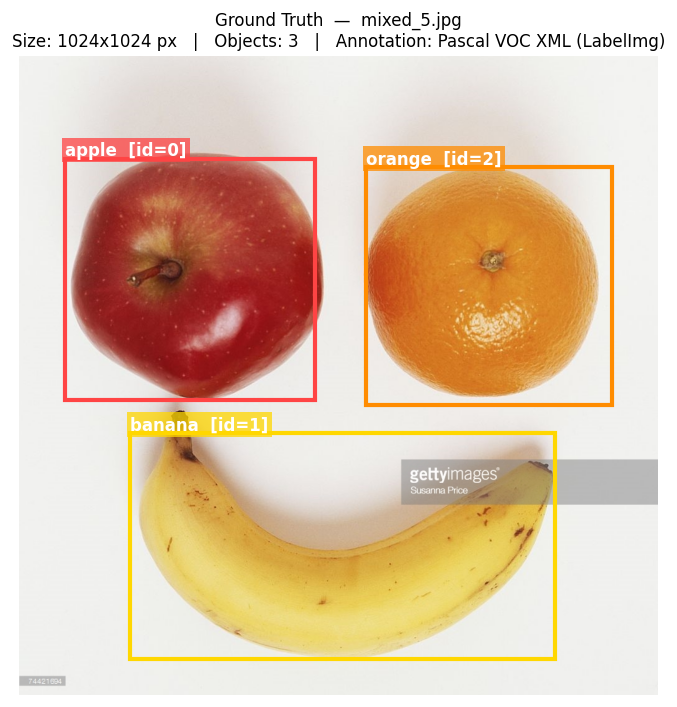

Annotation source : mixed_5.xml  (Pascal VOC XML)
  [orange  ]  xmin= 556  ymin= 178  xmax= 950  ymax= 559
  [apple   ]  xmin=  73  ymin= 164  xmax= 474  ymax= 550
  [banana  ]  xmin= 177  ymin= 604  xmax= 858  ymax= 966


In [5]:
def visualize_ground_truth(image_path):
    """
    Load an image and its Pascal VOC XML, then draw ground-truth
    bounding boxes with class labels using OpenCV + Matplotlib.
    """
    xml_path = xml_path_for(image_path)
    if not os.path.exists(xml_path):
        print(f'[WARN] No XML found for {image_path}')
        return None, []

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    annotations, img_w, img_h = parse_voc_xml(xml_path)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img_rgb)
    ax.set_title(
        f'Ground Truth  —  {os.path.basename(image_path)}\n'
        f'Size: {img_w}x{img_h} px   |   Objects: {len(annotations)}   |   '
        f'Annotation: Pascal VOC XML (LabelImg)',
        fontsize=10
    )
    ax.axis('off')

    for ann in annotations:
        color = CLASS_COLORS.get(ann['class_name'], '#00FF00')
        x1, y1 = ann['xmin'], ann['ymin']
        bw     = ann['xmax'] - x1
        bh     = ann['ymax'] - y1
        rect   = patches.Rectangle(
            (x1, y1), bw, bh,
            linewidth=2.5, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 6,
            f"{ann['class_name']}  [id={ann['class_id']}]",
            color='white', fontsize=10, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.75, pad=2, edgecolor='none')
        )

    plt.tight_layout()
    plt.show()

    print(f'Annotation source : {os.path.basename(xml_path)}  (Pascal VOC XML)')
    for ann in annotations:
        print(f"  [{ann['class_name']:8s}]  "
              f"xmin={ann['xmin']:4d}  ymin={ann['ymin']:4d}  "
              f"xmax={ann['xmax']:4d}  ymax={ann['ymax']:4d}")
    return img_rgb, annotations


random.seed(42)
sample_image_path = random.choice(train_images)
print(f'Randomly selected image: {sample_image_path}\n')
gt_img_rgb, gt_annotations = visualize_ground_truth(sample_image_path)

## Task 1 — Intersection over Union (IoU)

In [6]:
def compute_iou(box_a, box_b):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.

    Parameters
    ----------
    box_a, box_b : list or tuple  [x_min, y_min, x_max, y_max]

    Returns
    -------
    float : IoU score in [0.0, 1.0]
    """
    # Intersection rectangle
    ix_min = max(box_a[0], box_b[0])
    iy_min = max(box_a[1], box_b[1])
    ix_max = min(box_a[2], box_b[2])
    iy_max = min(box_a[3], box_b[3])

    inter_w    = max(0.0, ix_max - ix_min)
    inter_h    = max(0.0, iy_max - iy_min)
    inter_area = inter_w * inter_h

    area_a     = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b     = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union_area  = area_a + area_b - inter_area

    return 0.0 if union_area == 0 else inter_area / union_area


# Demonstrate on 3 hardcoded pairs
test_cases = [
    ('Highly overlapping   ', [50,  50,  200, 200], [80,  80,  220, 220]),
    ('Partially overlapping', [0,   0,   100, 100], [75,  75,  175, 175]),
    ('Completely disjoint  ', [0,   0,    50,  50], [100, 100, 150, 150]),
]

print('+--------------------------+----------------------+-------------+')
print('| Description              | Box A                |  IoU Score  |')
print('+--------------------------+----------------------+-------------+')
for desc, ba, bb in test_cases:
    iou = compute_iou(ba, bb)
    print(f'| {desc} | {str(ba):<20s} |  {iou:.6f}  |')
print('+--------------------------+----------------------+-------------+')

+--------------------------+----------------------+-------------+
| Description              | Box A                |  IoU Score  |
+--------------------------+----------------------+-------------+
| Highly overlapping    | [50, 50, 200, 200]   |  0.519856  |
| Partially overlapping | [0, 0, 100, 100]     |  0.032258  |
| Completely disjoint   | [0, 0, 50, 50]       |  0.000000  |
+--------------------------+----------------------+-------------+


## Task 2 —  Selective Search (R-CNN Step 1)

Image for Selective Search: /kaggle/input/datasets/mbkinaci/fruit-images-for-object-detection/train_zip/train/banana_17.jpg
Dimensions: 640 x 620 px
Total proposals  : 650
Using top-200.


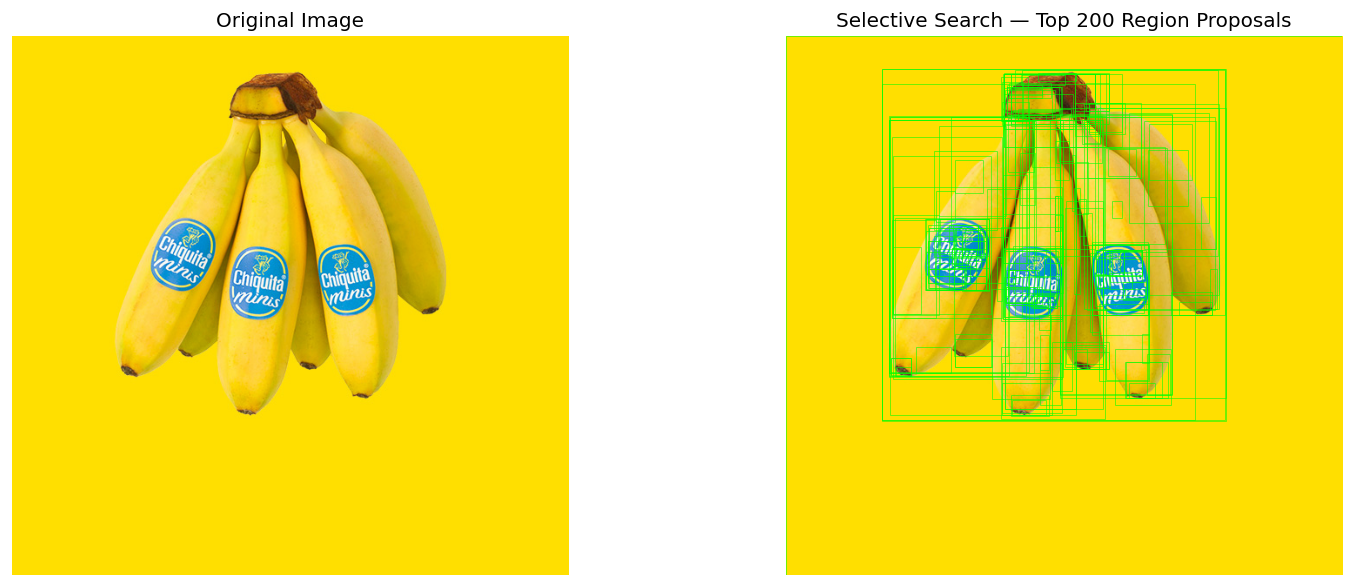

In [7]:
random.seed(7)
ss_image_path = random.choice(train_images)
print(f'Image for Selective Search: {ss_image_path}')

ss_img_bgr = cv2.imread(ss_image_path)
ss_img_rgb = cv2.cvtColor(ss_img_bgr, cv2.COLOR_BGR2RGB)
ss_img_h, ss_img_w = ss_img_rgb.shape[:2]
print(f'Dimensions: {ss_img_w} x {ss_img_h} px')

# Selective Search  (fast mode)
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(ss_img_bgr)
ss.switchToSelectiveSearchFast()

all_rects     = ss.process()    # (x, y, w, h)
proposals_200 = all_rects[:200]
print(f'Total proposals  : {len(all_rects)}')
print(f'Using top-200.')

# Convert (x,y,w,h) -> (x_min, y_min, x_max, y_max)  for Tasks 3 & 4
proposals_xyxy = np.array(
    [[x, y, x+w, y+h] for (x, y, w, h) in proposals_200],
    dtype=np.float32
)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(ss_img_rgb)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(ss_img_rgb)
axes[1].set_title('Selective Search — Top 200 Region Proposals', fontsize=12)
axes[1].axis('off')
for (x, y, w, h) in proposals_200:
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=0.6, edgecolor='lime', facecolor='none', alpha=0.55
    )
    axes[1].add_patch(rect)
plt.tight_layout()
plt.show()

## Task 3 — Sequential Crop + CNN Forward Pass

In [8]:
# ResNet-18 without avgpool + fc  =>  outputs (B, 512, H/32, W/32)
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-2])
feature_extractor.eval().to(DEVICE)

crop_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

pil_ss = Image.fromarray(ss_img_rgb)
TOP_N  = 100
rcnn_features = []

print(f'Running R-CNN-style sequential inference on {TOP_N} proposals ...')
t_rcnn_start = time.perf_counter()

with torch.no_grad():
    for x_min, y_min, x_max, y_max in proposals_xyxy[:TOP_N]:
        x0 = max(0, int(x_min));  y0 = max(0, int(y_min))
        x1 = min(ss_img_w, int(x_max));  y1 = min(ss_img_h, int(y_max))
        crop = pil_ss.crop((x0, y0, x1, y1))
        if crop.width == 0 or crop.height == 0:
            continue
        inp  = crop_transform(crop).unsqueeze(0).to(DEVICE)
        feat = feature_extractor(inp)   # (1, 512, 7, 7)
        rcnn_features.append(feat.cpu())

t_rcnn_end = time.perf_counter()
rcnn_time  = t_rcnn_end - t_rcnn_start

print()
print('=' * 50)
print('  Task 3  -  R-CNN Sequential Inference')
print(f'  Proposals processed  : {len(rcnn_features)}')
print(f'  Feature shape (each) : {rcnn_features[0].shape}')
print(f'  Total execution time : {rcnn_time:.4f} seconds')
print(f'  Time per crop        : {rcnn_time/len(rcnn_features)*1000:.2f} ms')
print('=' * 50)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Running R-CNN-style sequential inference on 100 proposals ...

  Task 3  -  R-CNN Sequential Inference
  Proposals processed  : 100
  Feature shape (each) : torch.Size([1, 512, 7, 7])
  Total execution time : 0.5202 seconds
  Time per crop        : 5.20 ms


## Task 4 — Fast R-CNN: Single Forward Pass + RoI Pooling

In [9]:
# Preprocess full image once
full_tensor = crop_transform(pil_ss).unsqueeze(0).to(DEVICE)  # (1, 3, H, W)
_, _, inp_h, inp_w = full_tensor.shape
print(f'Full image tensor : {full_tensor.shape}')

t_fast_start = time.perf_counter()

# (a) ONE CNN forward pass => shared feature map
with torch.no_grad():
    feature_map = feature_extractor(full_tensor)   # (1, 512, inp_h/32, inp_w/32)

_, _, fm_h, fm_w = feature_map.shape
print(f'Feature map shape : {feature_map.shape}')

# (b) Spatial scale  =  feature_map_dim / input_dim  =  1/32 for ResNet-18
spatial_scale = fm_h / inp_h
print(f'Spatial scale     : {spatial_scale:.6f}  (= 1/{round(1/spatial_scale)})')

# (c) Rescale proposal coords: original image space -> 224x224 input space
scale_x = inp_w / ss_img_w
scale_y = inp_h / ss_img_h
rois_rescaled = proposals_xyxy[:TOP_N].copy()
rois_rescaled[:, [0, 2]] *= scale_x
rois_rescaled[:, [1, 3]] *= scale_y

# roi_pool expects (batch_idx, x1, y1, x2, y2)  — prepend zero batch column
batch_col   = np.zeros((rois_rescaled.shape[0], 1), dtype=np.float32)
rois_tensor = torch.from_numpy(np.hstack([batch_col, rois_rescaled])).to(DEVICE)

# (d) RoI Pooling — extract 7x7 features for all 100 RoIs in one call
with torch.no_grad():
    roi_features = ops.roi_pool(
        feature_map, rois_tensor,
        output_size=(7, 7),
        spatial_scale=float(spatial_scale)
    )

t_fast_end = time.perf_counter()
fast_time  = t_fast_end - t_fast_start

print(f'RoI features shape: {roi_features.shape}')
print()
print('=' * 50)
print('  Task 4  -  Fast R-CNN (1 pass + RoI Pool)')
print(f'  Total execution time : {fast_time:.4f} seconds')
print()
print('  Comparison')
print(f'  R-CNN  (Task 3)      : {rcnn_time:.4f} s')
print(f'  Fast R-CNN (Task 4)  : {fast_time:.4f} s')
print(f'  Speedup              : {rcnn_time / fast_time:.1f}x')
print('=' * 50)

Full image tensor : torch.Size([1, 3, 224, 224])
Feature map shape : torch.Size([1, 512, 7, 7])
Spatial scale     : 0.031250  (= 1/32)
RoI features shape: torch.Size([100, 512, 7, 7])

  Task 4  -  Fast R-CNN (1 pass + RoI Pool)
  Total execution time : 0.0055 seconds

  Comparison
  R-CNN  (Task 3)      : 0.5202 s
  Fast R-CNN (Task 4)  : 0.0055 s
  Speedup              : 94.5x


### Task 4

**Q: What redundant mathematical operations does Fast R-CNN eliminate to achieve this efficiency?**

In R-CNN every one of the *N* region proposals is independently cropped from the raw image, resized to 224×224, and fed through the full convolutional backbone — **N complete forward passes**. Pixels in overlapping proposals are convolved, batch-normalised, and activated multiple times: pure wasted computation.

Fast R-CNN eliminates this by running the backbone **exactly once** on the whole image to produce a single shared feature map. For each proposal, **RoI Pooling** projects the proposal's coordinates into feature-map space and extracts a fixed 7×7 descriptor directly from that shared map — no repeated convolutions at all. The total cost drops from *N* full CNN passes to **1 CNN pass + N cheap spatial crops on the feature map**, which is why the speedup above is so dramatic even for only 100 proposals.

## Task 5 — Faster R-CNN: Pre-trained Inference

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 199MB/s]


Raw predictions: 11
After filter (>= 0.8): 5 boxes


/tmp/ipykernel_24/4224680654.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(filt_boxes), 1))


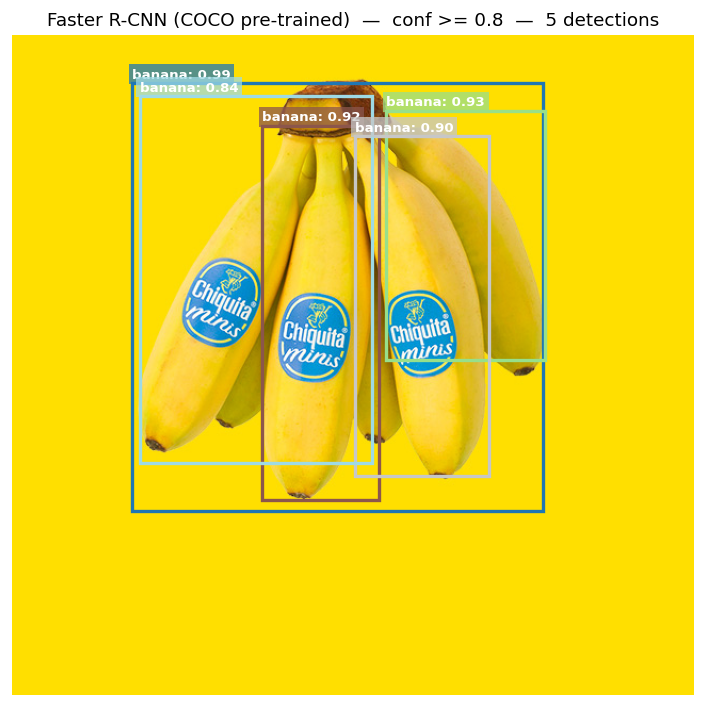

In [10]:
frcnn_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
frcnn_model   = fasterrcnn_resnet50_fpn(weights=frcnn_weights)
frcnn_model.eval().to(DEVICE)
COCO_NAMES = frcnn_weights.meta['categories']

frcnn_pil    = Image.open(ss_image_path).convert('RGB')
frcnn_tensor = T.ToTensor()(frcnn_pil).to(DEVICE)

with torch.no_grad():
    raw_out = frcnn_model([frcnn_tensor])[0]

all_boxes  = raw_out['boxes'].cpu().numpy()
all_labels = raw_out['labels'].cpu().numpy()
all_scores = raw_out['scores'].cpu().numpy()
print(f'Raw predictions: {len(all_boxes)}')


def filter_predictions(boxes, labels, scores, threshold=0.80):
    """Keep predictions with confidence >= threshold."""
    mask = scores >= threshold
    return boxes[mask], labels[mask], scores[mask]


CONF_THRESH = 0.80
filt_boxes, filt_labels, filt_scores = filter_predictions(
    all_boxes, all_labels, all_scores, CONF_THRESH
)
print(f'After filter (>= {CONF_THRESH}): {len(filt_boxes)} boxes')

np_img_frcnn = np.array(frcnn_pil)
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
ax.imshow(np_img_frcnn)
ax.set_title(
    f'Faster R-CNN (COCO pre-trained)  —  conf >= {CONF_THRESH}  —  {len(filt_boxes)} detections',
    fontsize=11
)
ax.axis('off')

cmap = plt.cm.get_cmap('tab20', max(len(filt_boxes), 1))
for i, (box, lbl, score) in enumerate(zip(filt_boxes, filt_labels, filt_scores)):
    x1, y1, x2, y2 = box
    color    = cmap(i)
    lbl_name = COCO_NAMES[lbl] if lbl < len(COCO_NAMES) else str(lbl)
    rect     = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1-5, f'{lbl_name}: {score:.2f}',
            color='white', fontsize=8, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.75, pad=2, edgecolor='none'))
plt.tight_layout()
plt.show()

### Task 5

**Q: How does the RPN eliminate the need for external algorithms like Selective Search?**

Selective Search is a *hand-crafted*, CPU-based algorithm that uses low-level pixel cues (colour, texture, fill) to hierarchically merge super-pixels into region candidates. It runs outside the neural network, is blind to semantics, and takes hundreds of milliseconds per image.

The **Region Proposal Network (RPN)** replaces this with a fully *learned* sub-network that lives inside the detector. After the shared backbone produces its feature map, the RPN slides a tiny convolutional head across every spatial location. At each location it evaluates *k* predefined anchor boxes (varying scale and aspect ratio) and predicts:
1. An **objectness score** — does this anchor contain any object?
2. **Box-regression offsets** — how to refine the anchor to tighter bounds?

The RPN operates directly on the backbone's already-computed feature map (shared at zero extra cost), so proposal generation adds only negligible runtime. Because those features already encode high-level semantics, RPN proposals are far more accurate than Selective Search candidates. Training RPN and detector jointly end-to-end is what makes Faster R-CNN approach real-time speed while maintaining high accuracy.

## Task 6 — Non-Maximum Suppression (NMS)

Boxes before custom NMS (conf >= 0.50) : 5
Boxes after  custom NMS (IoU <= 0.5) : 5


/tmp/ipykernel_24/2267072163.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = plt.cm.get_cmap('tab20', max(len(list(indices)), 1))


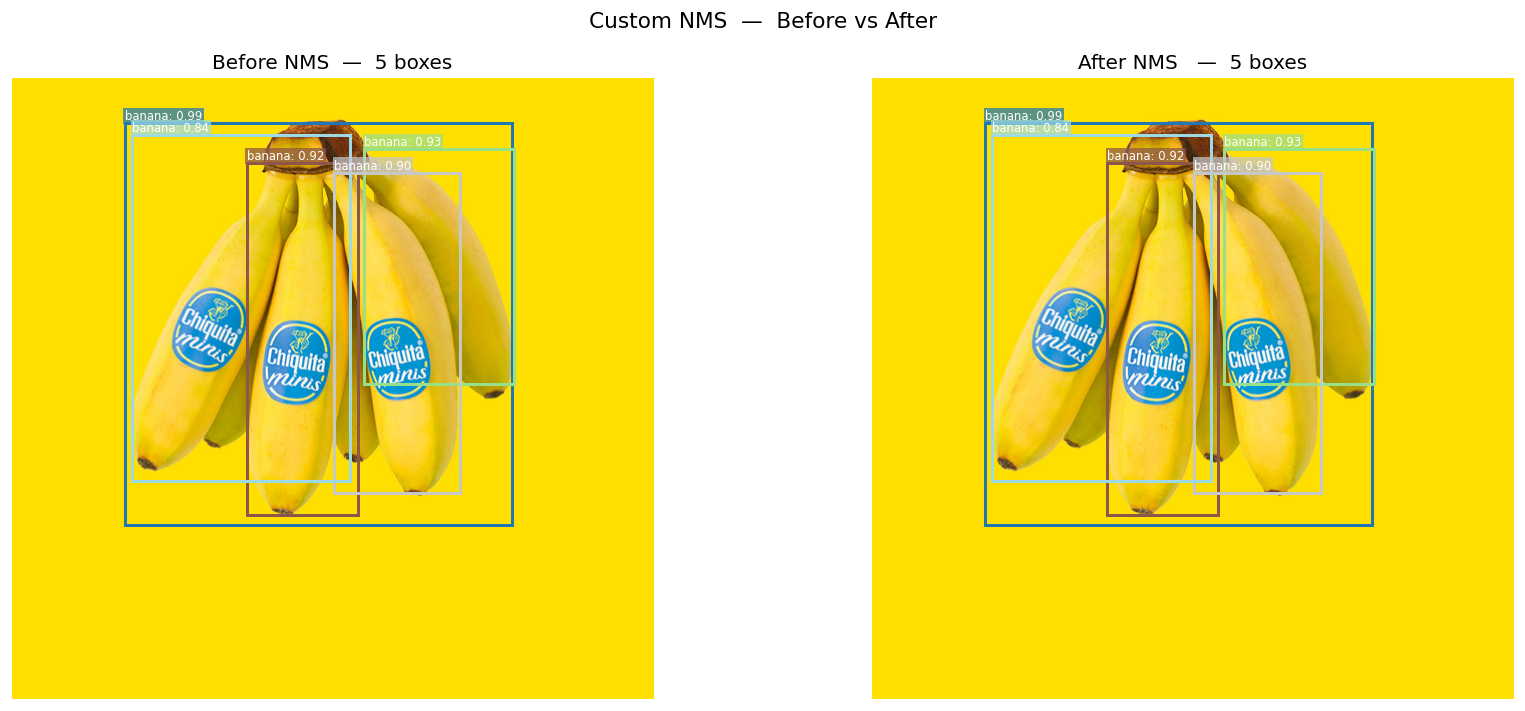

In [11]:
def custom_nms(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression built from scratch using compute_iou().

    Parameters
    ----------
    boxes         : list of [x_min, y_min, x_max, y_max]
    scores        : list of float confidence scores
    iou_threshold : float — boxes with IoU > threshold vs the selected box
                    are discarded

    Returns
    -------
    list of int — original indices of surviving boxes
    """
    if not boxes:
        return []

    boxes  = [list(b) for b in boxes]
    scores = list(scores)

    # Step 1: sort by descending confidence
    remaining = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    kept = []

    while remaining:
        # Step 2: pick the highest-scoring box
        best = remaining[0]
        kept.append(best)

        # Steps 3-4: compare with every remaining box via IoU
        new_remaining = []
        for idx in remaining[1:]:
            if compute_iou(boxes[best], boxes[idx]) <= iou_threshold:
                new_remaining.append(idx)   # keep if overlap is low enough

        remaining = new_remaining   # Step 5: repeat

    return kept


# Apply custom NMS to Faster R-CNN predictions (conf >= 0.50)
demo_mask   = all_scores >= 0.50
demo_boxes  = all_boxes[demo_mask].tolist()
demo_scores = all_scores[demo_mask].tolist()
demo_labels = all_labels[demo_mask].tolist()

NMS_THRESH = 0.50
kept_idx   = custom_nms(demo_boxes, demo_scores, iou_threshold=NMS_THRESH)

print(f'Boxes before custom NMS (conf >= 0.50) : {len(demo_boxes)}')
print(f'Boxes after  custom NMS (IoU <= {NMS_THRESH}) : {len(kept_idx)}')

# Before / After visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
panels = [
    (f'Before NMS  —  {len(demo_boxes)} boxes', range(len(demo_boxes))),
    (f'After NMS   —  {len(kept_idx)} boxes',   kept_idx),
]
for ax, (title, indices) in zip(axes, panels):
    ax.imshow(np_img_frcnn)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
    cmap2 = plt.cm.get_cmap('tab20', max(len(list(indices)), 1))
    for plot_i, orig_i in enumerate(indices):
        x1, y1, x2, y2 = demo_boxes[orig_i]
        color    = cmap2(plot_i)
        lbl_name = (COCO_NAMES[demo_labels[orig_i]]
                    if demo_labels[orig_i] < len(COCO_NAMES)
                    else str(demo_labels[orig_i]))
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1.8, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1-4, f'{lbl_name}: {demo_scores[orig_i]:.2f}',
                color='white', fontsize=7,
                bbox=dict(facecolor=color, alpha=0.72, pad=1, edgecolor='none'))
plt.suptitle('Custom NMS  —  Before vs After', fontsize=13)
plt.tight_layout()
plt.show()

### Task 6

**Q: How does the IoU threshold affect detection of tightly packed objects (e.g., apples in a basket)?**

The NMS IoU threshold controls how much overlap is tolerated before a lower-scoring box is suppressed.

| Threshold | Effect on a dense fruit cluster |
|-----------|----------------------------------|
| **Very low (0.1)** | Any two boxes sharing even 10% of their area get merged. Neighbouring apple boxes naturally overlap by 20–50%, so NMS aggressively suppresses most of them, leaving only 1–2 survivors for a whole cluster. **Severe under-detection.** |
| **Very high (0.9)** | Only near-perfect duplicates (≥ 90% overlap) are removed. Boxes around neighbouring apples survive because their overlap is well below 0.9 — each apple keeps its own prediction. A small number of near-duplicate boxes for the same apple may also survive, causing **minor false duplicates**. |

**Rule of thumb:** use a **higher threshold (0.5–0.8)** for dense, tightly packed objects to preserve individual detections. Use a lower threshold for well-separated objects to aggressively clean up duplicates.

## Task 7 — YOLO Fine-Tuning on the Fruit Detection Dataset

### 7.1 — Convert Pascal VOC XML to YOLO TXT Labels

In [12]:
def voc_xml_to_yolo_txt(xml_path, out_label_dir):
    """
    Convert one Pascal VOC XML annotation to a YOLO .txt label file.

    YOLO format (one line per object):
        class_id  x_center  y_center  width  height
    All values are normalised to [0, 1].
    """
    annotations, img_w, img_h = parse_voc_xml(xml_path)
    if img_w <= 0 or img_h <= 0:
        raise ValueError(f'Invalid image size for {xml_path}')

    stem     = Path(xml_path).stem
    txt_path = Path(out_label_dir) / f'{stem}.txt'

    lines = []
    for ann in annotations:
        if ann['class_id'] < 0:
            continue
        if ann['xmax'] <= ann['xmin'] or ann['ymax'] <= ann['ymin']:
            continue
        x_c = ((ann['xmin'] + ann['xmax']) / 2.0) / img_w
        y_c = ((ann['ymin'] + ann['ymax']) / 2.0) / img_h
        bw  = (ann['xmax'] - ann['xmin']) / img_w
        bh  = (ann['ymax'] - ann['ymin']) / img_h
        lines.append(f"{ann['class_id']} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}")

    with open(txt_path, 'w') as f:
        f.write('\n'.join(lines))


# Build YOLO dataset layout expected by Ultralytics:
#   yolo_dataset/train/images/  +  yolo_dataset/train/labels/
#   yolo_dataset/test/images/   +  yolo_dataset/test/labels/
YOLO_ROOT = Path('yolo_dataset')

for split, img_list in [('train', train_images), ('test', test_images)]:
    img_dir = YOLO_ROOT / split / 'images'
    lbl_dir = YOLO_ROOT / split / 'labels'
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    ok = 0
    for img_path in img_list:
        xml = xml_path_for(img_path)
        if not os.path.exists(xml):
            print(f'  [SKIP] No XML: {img_path}')
            continue
        try:
            shutil.copy2(img_path, img_dir / Path(img_path).name)
            voc_xml_to_yolo_txt(xml, lbl_dir)
        except ValueError as exc:
            print(f'  [SKIP] {Path(img_path).name}: {exc}')
            continue
        ok += 1
    print(f'[{split:5s}]  {ok}/{len(img_list)} images converted.')

print('\nYOLO dataset directory created successfully.')

[train]  240/240 images converted.
[test ]  60/60 images converted.

YOLO dataset directory created successfully.


### 7.2 — Create the Dataset YAML Config

In [13]:
import yaml

cfg = {
    'path' : str(YOLO_ROOT.resolve()),
    'train': 'train/images',
    'val'  : 'test/images',
    'test' : 'test/images',
    'nc'   : len(CLASS_NAMES),
    'names': CLASS_NAMES,
}

YAML_PATH = 'fruit_yolo.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

print('YAML written to', YAML_PATH)
print(open(YAML_PATH).read())

YAML written to fruit_yolo.yaml
names:
- apple
- banana
- orange
nc: 3
path: /kaggle/working/yolo_dataset
test: test/images
train: train/images
val: test/images



### 7.3 — Pre-trained YOLOv8n Baseline Inference (Before Fine-tuning)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
3 test images selected for inference:
  /kaggle/input/datasets/mbkinaci/fruit-images-for-object-detection/test_zip/test/banana_83.jpg
  /kaggle/input/datasets/mbkinaci/fruit-images-for-object-detection/test_zip/test/banana_82.jpg
  /kaggle/input/datasets/mbkinaci/fruit-images-for-object-detection/test_zip/test/apple_89.jpg

Average inference time (pre-trained): 13.62 ms/image


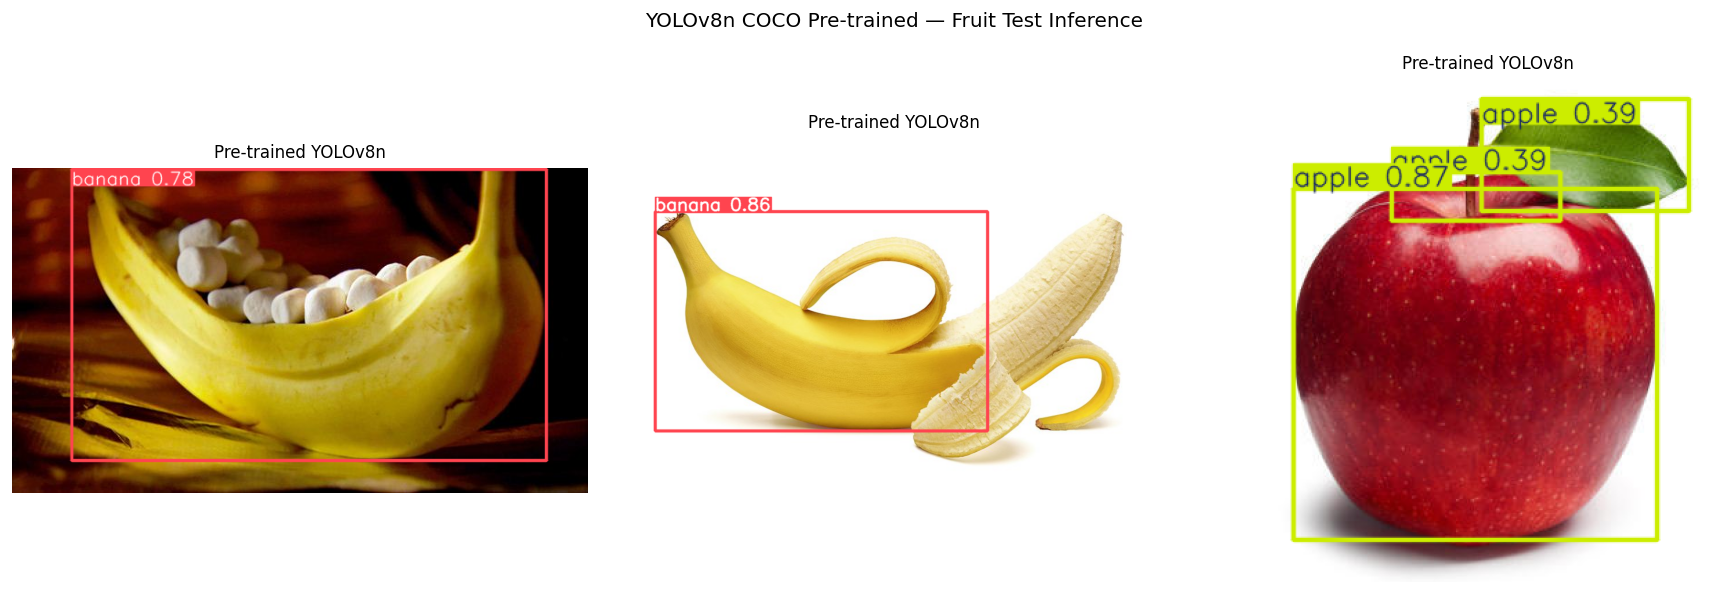

In [14]:
from ultralytics import YOLO

yolo_pretrained = YOLO('yolov8n.pt')

random.seed(99)
test_sample_paths = random.sample(test_images, min(3, len(test_images)))
print('3 test images selected for inference:')
for p in test_sample_paths:
    print(' ', p)

pretrained_results = yolo_pretrained.predict(
    source=test_sample_paths, conf=0.25, save=False, verbose=False
)
pretrained_times = [r.speed['inference'] for r in pretrained_results]
avg_pretrained_ms = np.mean(pretrained_times)
print(f'\nAverage inference time (pre-trained): {avg_pretrained_ms:.2f} ms/image')

fig, axes = plt.subplots(1, len(pretrained_results), figsize=(5*len(pretrained_results), 5))
if len(pretrained_results) == 1:
    axes = [axes]
for ax, res in zip(axes, pretrained_results):
    ax.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title('Pre-trained YOLOv8n', fontsize=10)
    ax.axis('off')
plt.suptitle('YOLOv8n COCO Pre-trained — Fruit Test Inference', fontsize=12)
plt.tight_layout()
plt.show()

### 7.4 — Fine-tune YOLOv8n (>= 10 epochs)

In [15]:
yolo_ft = YOLO('yolov8n.pt')

yolo_ft.train(
    data    = YAML_PATH,
    epochs  = 50,         # >= 10 as required; 50 for better convergence on 240 images
    imgsz   = 640,
    batch   = 16,
    name    = 'yolov8n_fruit',
    project = 'runs/detect',
    patience= 15,
    device  = 0 if torch.cuda.is_available() else 'cpu',
    verbose = True,
    plots   = True,
)

best_weights_path = str(yolo_ft.trainer.best)
print(f'\nBest weights saved: {best_weights_path}')

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.5.1+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=fruit_yolo.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_fruit, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspectiv

### 7.5 — Evaluate: mAP@50 and mAP@50-95 on Test Set

In [16]:
yolo_best = YOLO(best_weights_path)

eval_metrics = yolo_best.val(data=YAML_PATH, split='test', verbose=True)

map50    = eval_metrics.box.map50
map50_95 = eval_metrics.box.map
prec_ft  = eval_metrics.box.mp
rec_ft   = eval_metrics.box.mr

print()
print('=' * 44)
print('  Fine-tuned YOLOv8n  -  Test Set Results')
print('=' * 44)
print(f'  mAP@50      : {map50:.4f}')
print(f'  mAP@50-95   : {map50_95:.4f}')
print(f'  Precision   : {prec_ft:.4f}')
print(f'  Recall      : {rec_ft:.4f}')
print('=' * 44)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.5.1+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1521.9±821.6 MB/s, size: 85.9 KB)
val: Scanning /kaggle/working/yolo_dataset/test/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 19.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.2it/s 1.9s
                   all         60        117       0.88      0.875      0.936       0.71
                 apple         24         35      0.803      0.929      0.948      0.792
                banana         22         40      0.917       0.85      0.924      0.613
                orange         22         42      0.922      0.846      0.937      0.725
Speed: 5.8ms preprocess, 9.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /kaggle/working/runs/d

### 7.6 — Inference on 3 Test Images with Fine-tuned Weights

Average inference time (fine-tuned): 2.96 ms/image


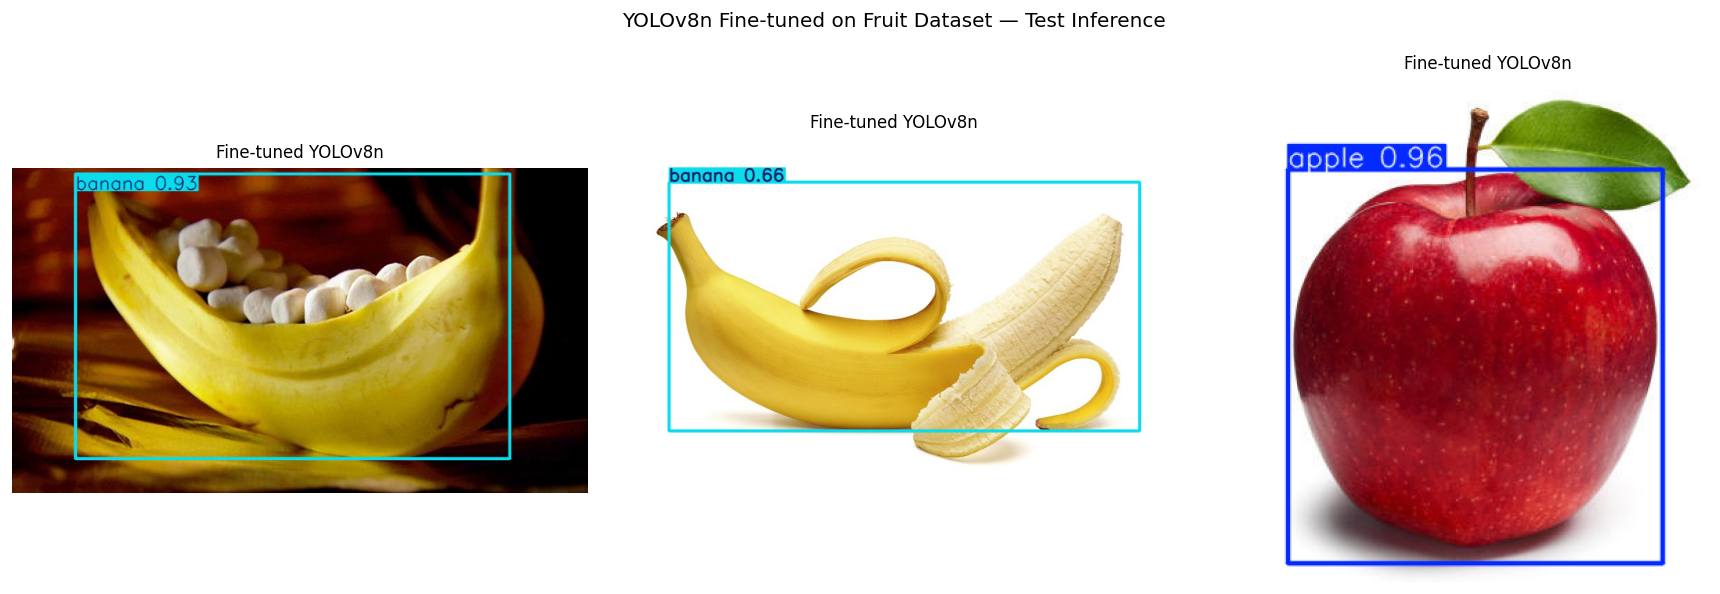

In [17]:
ft_results  = yolo_best.predict(
    source=test_sample_paths, conf=0.25, save=False, verbose=False
)
avg_ft_ms   = np.mean([r.speed['inference'] for r in ft_results])
print(f'Average inference time (fine-tuned): {avg_ft_ms:.2f} ms/image')

fig, axes = plt.subplots(1, len(ft_results), figsize=(5*len(ft_results), 5))
if len(ft_results) == 1:
    axes = [axes]
for ax, res in zip(axes, ft_results):
    ax.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title('Fine-tuned YOLOv8n', fontsize=10)
    ax.axis('off')
plt.suptitle('YOLOv8n Fine-tuned on Fruit Dataset — Test Inference', fontsize=12)
plt.tight_layout()
plt.show()

### 7.7 — Benchmark Faster R-CNN on the Same 3 Test Images

In [18]:
frcnn_times, frcnn_precs, frcnn_recs = [], [], []

for img_path in test_sample_paths:
    img_pil    = Image.open(img_path).convert('RGB')
    img_tensor = T.ToTensor()(img_pil).to(DEVICE)

    # Ground-truth from Pascal VOC XML
    gt_anns, gt_w, gt_h = parse_voc_xml(xml_path_for(img_path))
    gt_boxes = [[a['xmin'], a['ymin'], a['xmax'], a['ymax']] for a in gt_anns]

    t0 = time.perf_counter()
    with torch.no_grad():
        preds = frcnn_model([img_tensor])[0]
    t1 = time.perf_counter()
    frcnn_times.append((t1 - t0) * 1000)

    pred_boxes  = preds['boxes'].cpu().numpy()
    pred_scores = preds['scores'].cpu().numpy()
    det_boxes   = pred_boxes[pred_scores >= 0.5].tolist()

    tp, matched = 0, set()
    for pb in det_boxes:
        for gi, gb in enumerate(gt_boxes):
            if gi not in matched and compute_iou(pb, gb) >= 0.5:
                tp += 1; matched.add(gi); break
    frcnn_precs.append(tp / len(det_boxes) if det_boxes else 0.0)
    frcnn_recs.append(tp  / len(gt_boxes)  if gt_boxes  else 0.0)

avg_frcnn_ms   = np.mean(frcnn_times)
avg_frcnn_prec = np.mean(frcnn_precs)
avg_frcnn_rec  = np.mean(frcnn_recs)
print(f'Faster R-CNN  {avg_frcnn_ms:.1f} ms | prec={avg_frcnn_prec:.3f} | rec={avg_frcnn_rec:.3f}')

# Pre-trained YOLO eval
pt_eval      = yolo_pretrained.val(data=YAML_PATH, split='test', verbose=False)
pt_prec      = pt_eval.box.mp
pt_rec       = pt_eval.box.mr
pt_map50     = pt_eval.box.map50
pt_map50_95  = pt_eval.box.map
print(f'YOLO pre-train prec={pt_prec:.4f} | rec={pt_rec:.4f}')

Faster R-CNN  63.7 ms | prec=0.325 | rec=1.000
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.5.1+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2173.0±1431.4 MB/s, size: 93.9 KB)
val: Scanning /kaggle/working/yolo_dataset/test/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 22.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.3it/s 1.7s
                   all         60        117      0.266      0.129      0.153     0.0998
Speed: 6.4ms preprocess, 5.7ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2
YOLO pre-train prec=0.2655 | rec=0.1286


### 7.8 — Model Comparison Table

In [19]:
from IPython.display import display, HTML

rows = [
    {
        'Model'          : 'Faster R-CNN (COCO pre-trained)',
        'Inference (ms)' : f'{avg_frcnn_ms:.1f}',
        'Precision'      : f'{avg_frcnn_prec:.4f}',
        'Recall'         : f'{avg_frcnn_rec:.4f}',
        'mAP@50'         : 'N/A',
        'mAP@50-95'      : 'N/A',
    },
    {
        'Model'          : 'YOLOv8n (COCO pre-trained)',
        'Inference (ms)' : f'{avg_pretrained_ms:.2f}',
        'Precision'      : f'{pt_prec:.4f}',
        'Recall'         : f'{pt_rec:.4f}',
        'mAP@50'         : f'{pt_map50:.4f}',
        'mAP@50-95'      : f'{pt_map50_95:.4f}',
    },
    {
        'Model'          : 'YOLOv8n (fine-tuned on Fruit)',
        'Inference (ms)' : f'{avg_ft_ms:.2f}',
        'Precision'      : f'{prec_ft:.4f}',
        'Recall'         : f'{rec_ft:.4f}',
        'mAP@50'         : f'{map50:.4f}',
        'mAP@50-95'      : f'{map50_95:.4f}',
    },
]

headers = list(rows[0].keys())
html = ('<table border="1" style="border-collapse:collapse;text-align:center;'
        'font-size:14px;font-family:sans-serif">')
html += '<tr style="background:#1a1a2e;color:#fff;">'
for h in headers:
    html += f'<th style="padding:9px 18px">{h}</th>'
html += '</tr>'

row_bg = ['#fdf6f0', '#eef3fb', '#e8f5e9']
for i, row in enumerate(rows):
    html += f'<tr style="background:{row_bg[i]}">'
    for h in headers:
        html += f'<td style="padding:8px 16px">{row[h]}</td>'
    html += '</tr>'
html += '</table>'

display(HTML('<h3>Model Comparison  —  Fruit Detection Dataset</h3>' + html))

Model,Inference (ms),Precision,Recall,mAP@50,mAP@50-95
Faster R-CNN (COCO pre-trained),63.7,0.3254,1.0000,N/A,N/A
YOLOv8n (COCO pre-trained),13.62,0.2655,0.1286,0.1534,0.0998
YOLOv8n (fine-tuned on Fruit),2.96,0.8805,0.8751,0.9362,0.7100
